# La distribuzione di Maxwell - Boltzmann

In meccanica classica, la velocit\`a delle molecole di un gas ideale in condizioni stazionarie \`e distribuita secondo una densit\`a di probabilit\`a definita da Maxwell e Boltzmann come:

$f(v) = \sqrt{\frac{2}{\pi}}\frac{v^2}{a^3}e^{-\frac{v^2}{2a^2}}$

dove la costante $a$ dipende dalla temperatura del gas, dalla massa delle molecole che lo compongono e dalla costante di Boltzmann: $a=\sqrt{k_BT/m}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lib import sezioneAureaMax, bisezione, generate_TAC, sturges_c
from stats import stats
from trapezi import integra_tr
from hit_or_miss import integral_hom


In [2]:
def maxwell_boltzmann (v, a):
    prefactor = 0.7978845608028654 / a**3
    return prefactor * v**2 * np.exp(-v**2/(2*a**2))

## Punto 1

Fissato il valore di $a=300$~m/s, si disegni la distribuzione $f(v)$ su un intervallo che ne comprenda la regione non nulla e se ne determini il massimo utilizzando il metodo della sezione aurea. Si indichi inoltre nel disegno la posizione del massimo trovato.

In [3]:
a = 300 # m/s
mb = lambda x : maxwell_boltzmann (x, a)
massimo = sezioneAureaMax (mb, 0, 2000, 0.001)

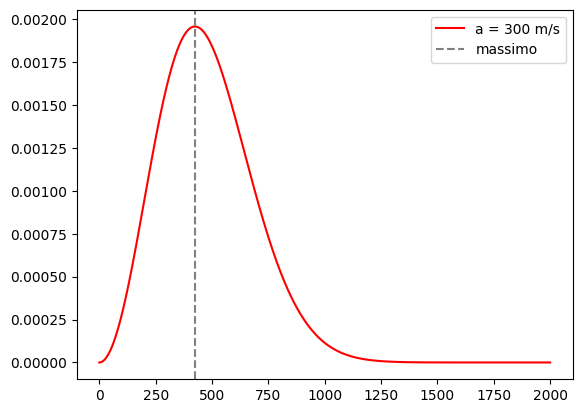

In [4]:
x_coord = np.linspace (0, 2000, 1000)
fig, ax = plt.subplots (nrows = 1, ncols = 1)
#ax.set_yscale ('log')
ax.plot (x_coord, mb (x_coord), color = 'red'  , label = 'a = 300 m/s')
ax.axvline (x=massimo, color = 'gray', linestyle = '--', label = 'massimo')
ax.legend ()

## Punto 2

Si generi un campione di 10,000 velocit\`a distribuite secondo quella distribuzione utilizzando la tecnica di \textit{try and catch}. Come si pu\`o determinare con un algoritmo, il modo intelligente, l'estremo superiore dell'intervallo di generazione sull'asse orizzontale?

Per determinare l'intervallo di generazione, si trova l'estremo a destra con il metodo della bisezione: si cerca il punto dove la pdf diventa una frazione fissa dell'altezza massima: f(v,a) = massimo, che significa f(v,a)-massimo = 0

1357.2083280698735


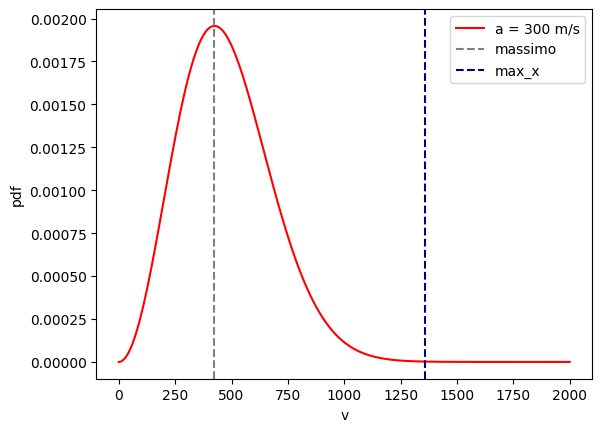

In [5]:
# trovo l'estremo superiore per la generazione dei numeri casuali

min_fracion = 0.001
mb_shift = lambda x : mb (x) - min_fracion * mb (massimo)
max_x = bisezione (mb_shift, massimo, 2000)
print (max_x)

x_coord = np.linspace (0, 2000, 1000)
fig, ax = plt.subplots (nrows = 1, ncols = 1)
#ax.set_yscale ('log')
ax.plot (x_coord, mb (x_coord), color = 'red'  , label = 'a = 300 m/s')
ax.axvline (x = massimo, color = 'gray', linestyle = '--', label = 'massimo')
ax.axvline (x = max_x, color = 'navy', linestyle = '--', label = 'max_x')
ax.set_xlabel ('v')
ax.set_ylabel ('pdf')
ax.legend ()


In [6]:
# generazione dei numeri casuali

N_points = 10_000
campione = generate_TAC (mb, 0, max_x, mb (massimo), N_points)

Text(0, 0.5, 'histogram')

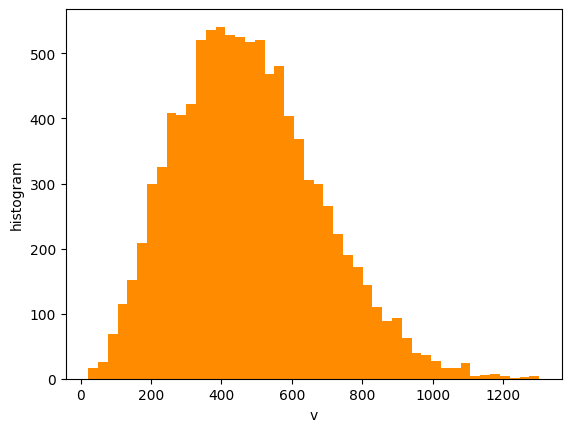

In [7]:
fig, ax = plt.subplots (nrows = 1, ncols = 1)
ax.hist (campione, bins = sturges_c (campione), color = 'darkorange')
ax.set_xlabel ('v')
ax.set_ylabel ('histogram')

## Punto 3

Si calcolino esplicitamente moda, media, mediana, deviazione standard, asimmetria e curtosi della distribuzione a partire dal campione generato in precedenza e si stampino i valori a schermo e si disegnino le stime della posizione della distribuzione sovrapposte alla distribuzione. Quale \`e la precisione con la quale \`e nota la media?

moda = 0.002
media = 4.8e+02
mediana = 4.6e+02
dev.st. = 2e+02
asimm. = 0.48
curt. = 0.057

precisione sulla media: 2.03


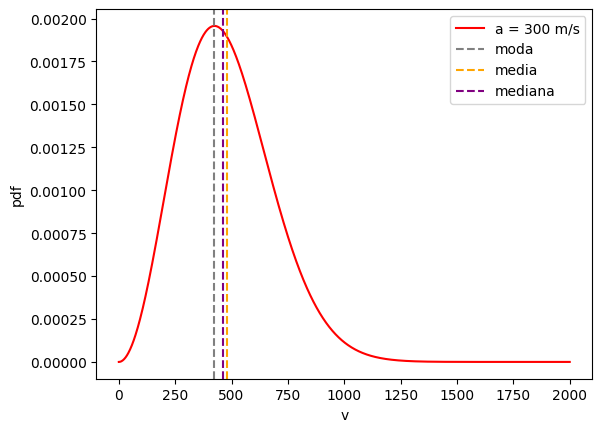

In [8]:
stats_mb = stats (campione)
print (f'moda = {mb(massimo):.2g}')
print (f'media = {stats_mb.mean ():.2g}')
print (f'mediana = {stats_mb.median ():.2g}')
print (f'dev.st. = {stats_mb.sigma ():.2g}')
print (f'asimm. = {stats_mb.skewness ():.2g}')
print (f'curt. = {stats_mb.kurtosis ():.2g}')

print ()
print (f'precisione sulla media: {stats_mb.sigma_mean ():.2f}')


x_coord = np.linspace (0, 2000, 1000)
fig, ax = plt.subplots (nrows = 1, ncols = 1)
#ax.set_yscale ('log')
ax.plot (x_coord, mb (x_coord), color = 'red'  , label = 'a = 300 m/s')
ax.axvline (x = massimo, color = 'gray', linestyle = '--', label = 'moda')
ax.axvline (x = stats_mb.mean (), color = 'orange', linestyle = '--', label = 'media')
ax.axvline (x = stats_mb.median (), color = 'purple', linestyle = '--', label = 'mediana')
ax.set_xlabel ('v')
ax.set_ylabel ('pdf')
ax.legend ()


## Punto 4

Una nota tecnica di integrazione consiste nel dividere l'asse orizzontale in segmenti di uguale lunghezza e di calcolare l'area della funzione sottesa come la somma dell'area dei trapezi rettangoli che hanno come altezza ciascun segmento e come basi i valori dell'integranda agli estremi del segmento.
Si costruisca una libreria in Python che implementi questo algoritmo e si verifichi con questo algoritmo se la distribuzione di Maxwell-Boltzmann \`e normalizzata e che la mediana divide effettivamente il campione in due parti.

In [9]:
N_points_int = 1000
area = integra_tr (mb, 0., max_x, N_points_int)
print (f"area della pdf nell'intervallo di generazione = {area:.3g}")
area = integra_tr (mb, 0., stats_mb.median (), N_points_int)
print (f"area della pdf a sinistra della mediana = {area:.3g}")

area della pdf nell'intervallo di generazione = 1
area della pdf a sinistra della mediana = 0.502


## Punto 5

Basandosi sulla funzione scritta precedentemente, si diesgni l'andamento della funzione cumulativa di $f(x,a)$.

In [10]:
y_coord = np.zeros (len (x_coord))
for i, x in enumerate (x_coord) : y_coord[i] = integra_tr (mb, 0, x, N_points_int)

Text(0, 0.5, 'CDF')

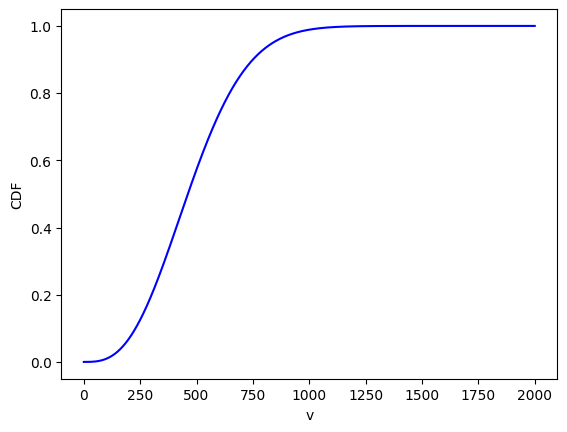

In [11]:
fig, ax = plt.subplots (nrows = 1, ncols = 1)
ax.plot (x_coord, y_coord, color = 'blue'  , label = 'a = 300 m/s')
ax.set_xlabel ('v')
ax.set_ylabel ('CDF')


Al crescere del numero di segmenti in cui \`e diviso l'intervallo di integrazione utilizzato per definire i trapezi, la precisione del metodo aumenta perch\'e la funzione risulta sempre meglio approssimata. Assumendo che l'incertezza associata ad un certo numero di divisioni possa essere calcolata come l'integrale ottenuto meno il valore calcolato con molte pi\`u divisioni, si studi l'andamento dell'errore in funzione del loro numero.

In [12]:
N_points_max = 1_000_000

points = []
integral = []
N_points_int = 10
while N_points_int <= N_points_max * 8 : 
    print (N_points_int)
    integral.append (integra_tr (mb, 0., max_x, N_points_int))
    points.append (N_points_int)
    N_points_int *= 2
    



10
20
40
80
160
320
640
1280
2560
5120
10240
20480
40960
81920
163840
327680
655360
1310720
2621440
5242880


Text(0, 0.5, 'errore stimato')

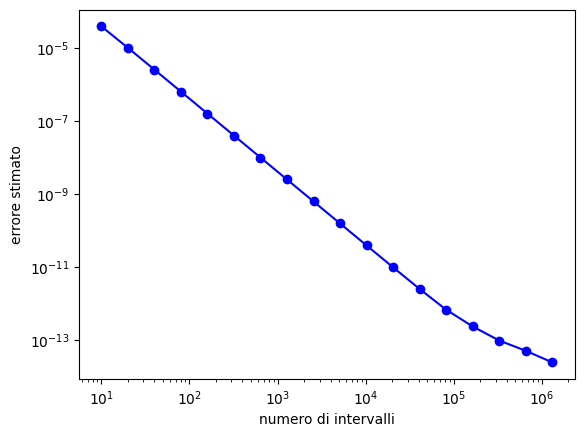

In [13]:
errors = []
# for i in range (len (integral)-2) : errors.append (abs (integral[i] - integral[i+2]))
for i in range (len (integral)-2) : errors.append (abs (integral[i] - integral[-1]))

fig, ax = plt.subplots (nrows = 1, ncols = 1)
ax.plot (points[:-2], errors, 'bo-')
ax.set_yscale ('log')
ax.set_xscale ('log')
ax.set_xlabel ('numero di intervalli')
ax.set_ylabel ('errore stimato')
